# Nonlinear expressions

Nonlinear models encode a scientific functional form while estimating interpretable parameters
of that function. This differs from splines, Gaussian processes, and other smoothers, which learn
an unknown function from the data. This notebook introduces Bambi's nonlinear formula interface
with two classical examples: enzyme kinetics and tree growth.

In [1]:
import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## Michaelis--Menten enzyme kinetics

The `Puromycin` dataset contains reaction rates measured at several substrate concentrations for
treated and untreated cells. It is distributed with R and described in the
[`datasets` documentation](https://search.r-project.org/R/refmans/datasets/html/Puromycin.html).

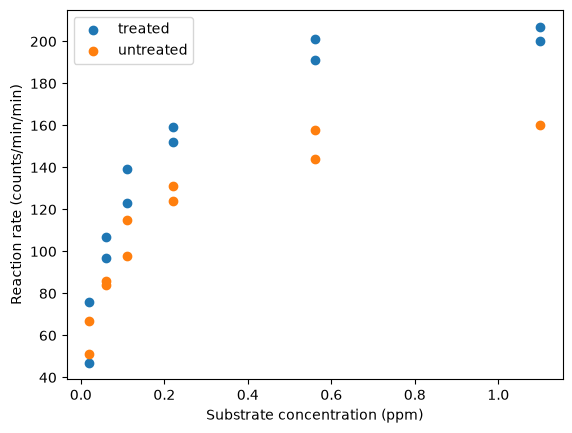

In [2]:
puromycin = pd.read_csv("data/puromycin.csv")
puromycin["state"] = puromycin["state"].astype("category")

for state, group in puromycin.groupby("state", observed=True):
    plt.scatter(group["concentration"], group["rate"], label=state)
plt.xlabel("Substrate concentration (ppm)")
plt.ylabel("Reaction rate (counts/min/min)")
plt.legend()
plt.show()


The Michaelis--Menten curve is

$$
\operatorname{rate}_i =
\frac{V_{\max,i} c_i}{K_{m,i} + c_i} + \epsilon_i.
$$

$V_{\max}$ is the asymptotic reaction rate and $K_m$ is the concentration at which the expected
rate reaches half of $V_{\max}$. The two parameters can differ between treated and untreated cells.
The main formula defines the nonlinear mean; the additional formulas use ordinary Formulae syntax
to describe each nonlinear parameter.

In [3]:
mm_formula = bmb.Formula(
    "rate ~ vmax * concentration / (km + concentration)",
    "vmax ~ 0 + state",
    "km ~ 0 + state",
    nlpars=("vmax", "km"),
)

mm_priors = {
    "vmax": {
        "state": bmb.Prior("LogNormal", mu=np.log(180), sigma=0.4),
    },
    "km": {
        "state": bmb.Prior("LogNormal", mu=np.log(0.1), sigma=0.7),
    },
    "sigma": bmb.Prior("HalfNormal", sigma=30),
}

mm_model = bmb.Model(mm_formula, puromycin, priors=mm_priors)
mm_idata = mm_model.fit(random_seed=123, progressbar=False)


The log-normal priors keep both scientific parameters positive. Because `0 + state` creates one
coefficient per treatment state, the model estimates a complete curve for each group rather than
a reference curve plus an unconstrained difference.

In [4]:
az.summary(mm_idata, var_names=["vmax_state", "km_state", "sigma"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
vmax_state[treated],213.2,7.1,200,220,2510,2408,1.00,0.14,0.11
vmax_state[untreated],162.2,7.9,150,170,2140,2239,1.00,0.17,0.14
km_state[treated],0.0655,0.0088,0.053,0.08,2674,2568,1.00,0.00017,0.00015
km_state[untreated],0.0512,0.0101,0.036,0.068,2180,2486,1.00,0.00021,0.00019
sigma,11.11,1.94,8.5,15,2451,2376,1.00,0.04,0.035


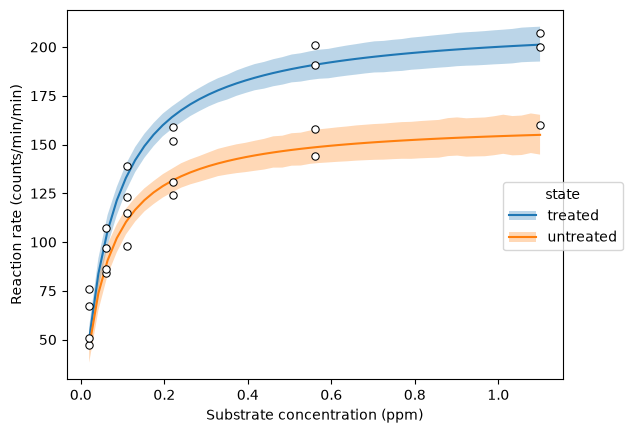

In [5]:
mm_fig = bmb.interpret.plot_predictions(
    mm_model,
    mm_idata,
    conditional=["concentration", "state"],
)
mm_ax = mm_fig.axes[0]
mm_ax.scatter(
    puromycin["concentration"],
    puromycin["rate"],
    facecolors="white",
    edgecolors="black",
    linewidths=0.75,
    s=28,
    zorder=3,
)
mm_ax.set_xlabel("Substrate concentration (ppm)")
mm_ax.set_ylabel("Reaction rate (counts/min/min)")
mm_fig


## Logistic growth of orange trees

The R `Orange` dataset follows the trunk circumference of five trees at seven ages. Its
[`datasets` documentation](https://stat.ethz.ch/R-manual/R-devel/library/datasets/html/Orange.html)
uses the three-parameter logistic growth curve

$$
y_{ij} = \frac{A_{ij}}{1 + \exp((x_{\mathrm{mid}} - x_{ij})/s)} + \epsilon_{ij},
$$

where $A$ is the asymptotic circumference, $x_{\mathrm{mid}}$ is the age at which the tree reaches
half that circumference, and $s$ controls the growth timescale.

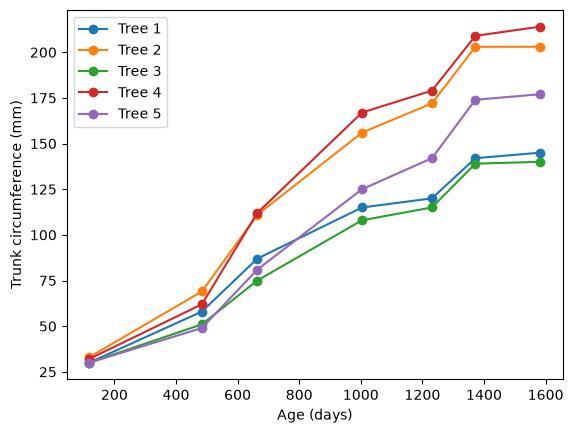

In [6]:
orange = pd.read_csv("data/orange.csv")
orange["age"] = orange["age"].astype(float)
orange["tree"] = orange["tree"].astype("category")

for tree, group in orange.groupby("tree", observed=True):
    plt.plot(group["age"], group["circumference"], "o-", label=f"Tree {tree}")
plt.xlabel("Age (days)")
plt.ylabel("Trunk circumference (mm)")
plt.legend()
plt.show()


Here the asymptote varies by tree while the midpoint and scale are shared. This combines a
nonlinear expression with Bambi's existing group-specific-effects machinery.

In [7]:
orange_formula = bmb.Formula(
    "circumference ~ asym / (1 + exp((xmid - age) / scale))",
    "asym ~ 1 + (1 | tree)",
    nlpars=("asym", "xmid", "scale"),
)

orange_priors = {
    "asym": {
        "Intercept": bmb.Prior("Normal", mu=190, sigma=30),
        "1|tree": bmb.Prior(
            "Normal",
            mu=0,
            sigma=bmb.Prior("HalfNormal", sigma=30),
        ),
    },
    "xmid": {
        "Intercept": bmb.Prior("Normal", mu=700, sigma=200),
    },
    "scale": {
        "Intercept": bmb.Prior("LogNormal", mu=np.log(350), sigma=0.4),
    },
    "sigma": bmb.Prior("HalfNormal", sigma=20),
}

orange_model = bmb.Model(orange_formula, orange, priors=orange_priors)
orange_idata = orange_model.fit(
    random_seed=123,
    target_accept=0.9,
    progressbar=False,
)


The fitted curves can be evaluated on a dense age grid for every tree even though `age` appears
only inside the nonlinear expression. The observations are overlaid to show how the modeled
growth trajectories relate to the measurements.

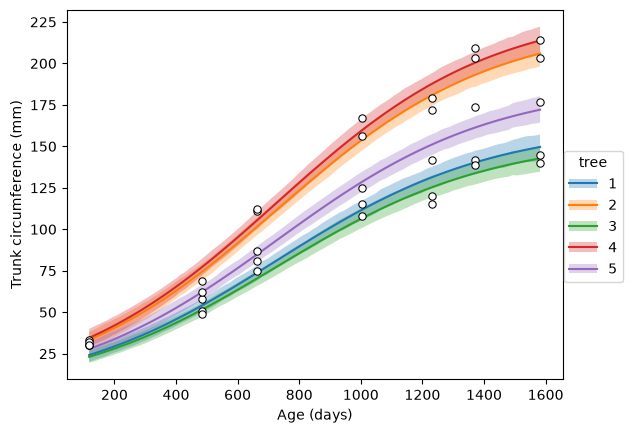

In [8]:
orange_fig = bmb.interpret.plot_predictions(
    orange_model,
    orange_idata,
    conditional={
        "age": np.linspace(orange["age"].min(), orange["age"].max(), 100),
        "tree": orange["tree"].cat.categories.tolist(),
    },
)
orange_ax = orange_fig.axes[0]
orange_ax.scatter(
    orange["age"],
    orange["circumference"],
    facecolors="white",
    edgecolors="black",
    linewidths=0.75,
    s=28,
    zorder=3,
)
orange_ax.set_xlabel("Age (days)")
orange_ax.set_ylabel("Trunk circumference (mm)")
orange_fig


## Formula anatomy

The main right-hand side is an arithmetic expression with no implicit intercept. For example,
`y ~ a + x` with `nlpars=("a",)` adds the observed `x` with coefficient one. To estimate that
coefficient, use `y ~ a + b * x` with `nlpars=("a", "b")`. The `nlpars` names identify modeled
nonlinear parameters. A parameter without an additional formula uses an intercept-only formula,
so omitting `b ~ 1` is equivalent to writing it explicitly. A literal `1` in the main expression
is the numeric value one; in an additional formula, `1` retains its ordinary intercept meaning.

Names in the main expression must be valid Python identifiers. Backtick-quoted column names are
not supported there. Rename columns containing spaces or dots before using them in an expression.
Additional parameter formulas retain ordinary Formulae syntax, including backtick-quoted names.

The implementation supports one univariate response and one nonlinear expression for a scalar
parent parameter. Binomial and Beta-Binomial count/trial responses written with
`prop(successes, trials)` are also supported. Other responses encoded as multiple columns,
including censored, truncated, weighted, or multiple responses, are not supported. Nonlinear
parameters must be declared in `nlpars` and cannot depend on one another. The order of `nlpars`
controls predictor construction and display.

## Supported operations and functions

Expressions support `+`, `-`, `*`, `/`, and `**`, together with these functions:

| Family | Functions |
|---|---|
| Basic | `exp`, `log`, `sqrt`, `log1p`, `expm1`, `softplus` |
| Trigonometric | `sin`, `cos`, `tan` |
| Inverse trigonometric | `asin`, `acos`, `atan`, `atan2` |
| Hyperbolic | `sinh`, `cosh`, `tanh` |
| Inverse hyperbolic | `asinh`, `acosh`, `atanh` |
| Error functions | `erf`, `erfc` |
| Probability transforms | `logit`, `invlogit`, `normal_cdf`, `normal_ppf`, `cloglog`, `invcloglog` |

The `arc` spellings `arcsin`, `arccos`, `arctan`, `arctan2`, `arcsinh`, `arccosh`, and
`arctanh` are aliases for their shorter counterparts. `expit` aliases `invlogit`; `norm_cdf` and
`norm_ppf` alias the corresponding `normal_` names. `probit` and `invprobit` alias `normal_ppf`
and `normal_cdf`, matching Bambi's link API. Angles are measured in radians. Inputs must satisfy
the mathematical domain of the function.

Explicit, scientifically meaningful priors are especially important because nonlinear models can
be weakly identified. Nonlinear predictor coefficients do not receive response-based automatic
prior scaling, even when `auto_scale=True`. Automatic scaling still applies to marginal likelihood
parameters such as Gaussian `sigma`.

## Prediction data and missing values

Prediction data must include every variable used by the nonlinear expression and parameter
formulas. For example:

In [9]:
new_data = pd.DataFrame(
    {
        "concentration": [0.05, 0.25, 0.75],
        "state": ["treated", "treated", "untreated"],
    }
)
new_predictions = mm_model.predict(
    mm_idata,
    data=new_data,
    inplace=False,
)
new_predictions.predictions

<xarray.DataTree 'predictions'>
Group: /predictions
    Dimensions:  (chain: 4, draw: 1000, __obs__: 3)
    Coordinates:
      * chain    (chain) int64 32B 0 1 2 3
      * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
      * __obs__  (__obs__) int64 24B 0 1 2
    Data variables:
        mu       (chain, draw, __obs__) float64 96kB 84.3 163.7 ... 167.8 134.8
    Attributes:
        created_at:                 2026-09-13T02:22:45.634560+00:00
        creation_library:           ArviZ
        creation_library_version:   1.3.0
        creation_library_language:  Python
        inference_library:          pymc
        inference_library_version:  6.3.2
        sample_dims:                ['chain', 'draw']


By default, missing values in the response, parameter formulas, or expression inputs raise an
error. With `dropna=True`, Bambi removes incomplete rows once across all these inputs so every part
of the model uses the same observations. Prediction data must always be complete.

## Auxiliary formulas and parent links

Additional formulas whose left-hand sides name family auxiliary parameters use ordinary Bambi
formulas. For example, observation noise can vary by treatment independently of the nonlinear
mean:

In [10]:
noise_formula = bmb.Formula(
    "y ~ a + b * exp(-k * x)",
    "a ~ 1 + treatment",
    "sigma ~ 1 + treatment",
    nlpars=("a", "b", "k"),
)


For a Gaussian model, `sigma` uses its usual log link. Auxiliary formulas can use observed
covariates, but cannot depend on nonlinear predictors or other modeled parameters. The parent
expression cannot refer to a modeled auxiliary parameter.

The nonlinear expression defines the parent on the family's link scale. The backend applies the
inverse link once after composing the expression. For a Poisson model with the default log link,
`count ~ a + b * exp(-x)` means $\mu_i = \exp(a_i + b_i\exp(-x_i))$. With an identity link, the
expression directly defines the parent. Nonlinear predictors retain identity links; only the
composed parent receives the family link transformation.

## Aliases and interpretation

Aliases change displayed and posterior variable names without changing expression symbols or
prior keys. Use nested mappings for nonlinear predictors:

In [11]:
orange_model.set_alias(
    {
        "circumference": "trunk_size",
        "mu": {"mu": "growth_curve"},
        "asym": {"asym": "asymptote", "Intercept": "mean_asymptote"},
        "sigma": "residual_sd",
    }
)


Set aliases before fitting; if aliases change after building, rebuild and fit before using the
posterior. Variables appearing directly in nonlinear expressions and variables in nonlinear
parameter formulas are available to `bmb.interpret.predictions`, `plot_predictions`,
`comparisons`, and `slopes`.